# P-Adic Quadtree Visualization of CTX Terrain

Visualize the Jezero DEM in its p-adic hierarchical form (Sierpinski-like decomposition)

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
from matplotlib.patches import Rectangle
from matplotlib.cm import get_cmap

sys.path.insert(0, str(Path.cwd().parent))
padic_path = '/Volumes/Fangorn/padic_fractal_analysis/src'
sys.path.insert(0, padic_path)

from padic import preprocessing, quadtree

print("✓ Imports successful")

✓ Imports successful


## Load Data and Build Quadtree

In [2]:
# Load DEM
data_dir = Path('/Volumes/Fangorn/padic_fractal_analysis/data')
dem_file = list(data_dir.glob('*.tif'))[0]
print(f"Loading: {dem_file.name}")

dem, metadata = preprocessing.load_dem(str(dem_file))
dem_clean, _ = preprocessing.preprocess_dem(dem)
print(f"✓ DEM shape: {dem_clean.shape}")

# Build quadtree
print("\nBuilding p-adic quadtree...")
qtree = quadtree.PadicQuadtree(dem_clean)
print(f"✓ Quadtree max_depth: {qtree.max_depth}")

Loading: JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif
✓ DEM shape: (1512, 1596)

Building p-adic quadtree...
✓ Quadtree max_depth: 11


## Visualization Functions

In [3]:
def visualize_quadtree_points(qtree, level_max=None, ax=None, color='black', s=1):
    """Plot quadtree nodes as points (Sierpinski-like visualization)."""
    if ax is None:
        ax = plt.gca()

    if level_max is None:
        level_max = min(qtree.max_depth, 12)

    queue = deque([qtree.root])
    points_by_level = {}

    while queue:
        node = queue.popleft()

        if node.level not in points_by_level:
            points_by_level[node.level] = []

        # Get center of node bounds
        min_row, max_row, min_col, max_col = node.bounds
        center_row = (min_row + max_row) / 2
        center_col = (min_col + max_col) / 2

        # Normalize to [0, 1]
        norm_row = center_row / qtree.height
        norm_col = center_col / qtree.width

        points_by_level[node.level].append((norm_col, norm_row))

        # Add children if not at max level
        if node.level < level_max and not node.is_leaf():
            queue.extend(node.children)

    # Plot points, with higher levels as smaller points
    for level in sorted(points_by_level.keys()):
        if level <= level_max:
            points = np.array(points_by_level[level])

            # Size decreases with level
            size = max(0.5, s * (1.0 / (2.0 ** (level / 2))))

            # Transparency increases with level
            alpha = min(1.0, 0.3 + 0.7 * (1.0 / (1.0 + level / 3)))

            ax.scatter(points[:, 0], points[:, 1],
                      s=size, c=color, alpha=alpha, rasterized=True)

    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    ax.set_xlabel('Column (normalized)', fontsize=10)
    ax.set_ylabel('Row (normalized)', fontsize=10)


def visualize_quadtree_variance(qtree, level_max=None, ax=None, cmap='hot'):
    """Plot quadtree nodes colored by elevation variance."""
    if ax is None:
        ax = plt.gca()

    if level_max is None:
        level_max = min(qtree.max_depth, 8)

    queue = deque([qtree.root])
    rectangles = []
    variances = []

    while queue:
        node = queue.popleft()

        if node.level <= level_max:
            min_row, max_row, min_col, max_col = node.bounds

            # Normalize to [0, 1]
            norm_row_min = min_row / qtree.height
            norm_row_max = max_row / qtree.height
            norm_col_min = min_col / qtree.width
            norm_col_max = max_col / qtree.width

            rectangles.append([norm_col_min, norm_row_min,
                             norm_col_max - norm_col_min,
                             norm_row_max - norm_row_min])
            variances.append(node.elevation_variance)

            if not node.is_leaf() and node.level < level_max:
                queue.extend(node.children)

    variances = np.array(variances)
    variances_norm = (variances - np.min(variances)) / (np.max(variances) - np.min(variances) + 1e-10)

    cmap_obj = get_cmap(cmap)

    for rect, var_norm in zip(rectangles, variances_norm):
        rect_patch = Rectangle((rect[0], rect[1]), rect[2], rect[3],
                              facecolor=cmap_obj(var_norm),
                              edgecolor='none', alpha=0.8)
        ax.add_patch(rect_patch)

    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    ax.set_xlabel('Column (normalized)', fontsize=10)
    ax.set_ylabel('Row (normalized)', fontsize=10)

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Visualization 1: P-Adic Form (Sierpinski-like)

Creating p-adic point visualization...
✓ Saved: padic_quadtree_sierpinski.png


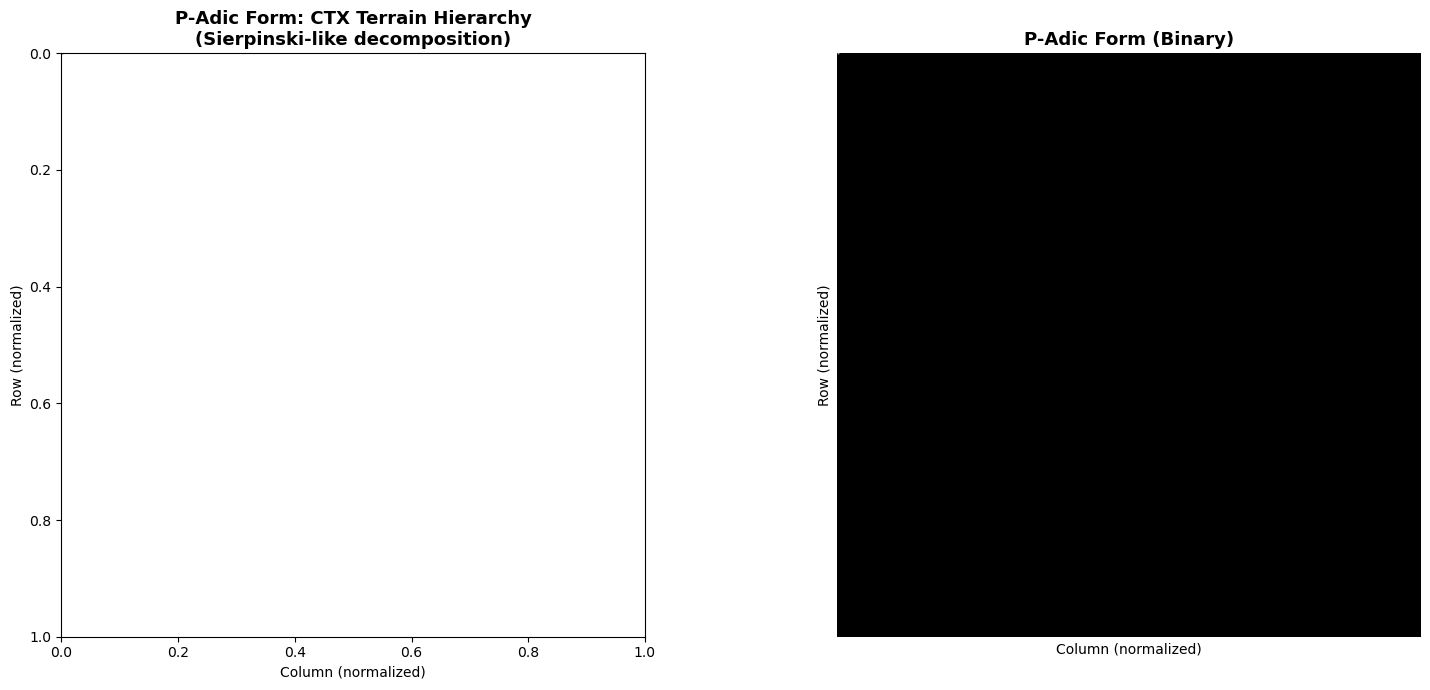

In [4]:
fig, (ax_padic, ax_binary) = plt.subplots(1, 2, figsize=(16, 7))

print("Creating p-adic point visualization...")
visualize_quadtree_points(qtree, level_max=11, ax=ax_padic, color='black', s=3)
ax_padic.set_title('P-Adic Form: CTX Terrain Hierarchy\n(Sierpinski-like decomposition)',
                   fontweight='bold', fontsize=13)

# Binary version (black and white)
visualize_quadtree_points(qtree, level_max=11, ax=ax_binary, color='white', s=3)
ax_binary.set_facecolor('black')
ax_binary.set_title('P-Adic Form (Binary)', fontweight='bold', fontsize=13)
ax_binary.spines['top'].set_visible(False)
ax_binary.spines['right'].set_visible(False)
ax_binary.spines['left'].set_visible(False)
ax_binary.spines['bottom'].set_visible(False)
ax_binary.set_xticks([])
ax_binary.set_yticks([])

plt.tight_layout()
plt.savefig('../padic_quadtree_sierpinski.png', dpi=150, bbox_inches='tight')
print("✓ Saved: padic_quadtree_sierpinski.png")
plt.show()

## Visualization 2: Multi-Panel Comparison

In [ ]:
fig = plt.figure(figsize=(18, 12))

# 1. P-adic point visualization
ax1 = plt.subplot(2, 3, 1)
print("Panel 1: P-adic structure...")
visualize_quadtree_points(qtree, level_max=10, ax=ax1, color='black', s=2)
ax1.set_title('P-Adic Quadtree Structure\n(Sierpinski-like point cloud)', fontweight='bold')

# 2. Detailed p-adic
ax2 = plt.subplot(2, 3, 2)
print("Panel 2: Detailed p-adic...")
visualize_quadtree_points(qtree, level_max=12, ax=ax2, color='darkblue', s=1.5)
ax2.set_title('P-Adic Structure (Extended levels)', fontweight='bold')

# 3. Variance-colored
ax3 = plt.subplot(2, 3, 3)
print("Panel 3: Variance-colored...")
visualize_quadtree_variance(qtree, level_max=7, ax=ax3, cmap='hot')
ax3.set_title('Quadtree Colored by Elevation Variance\n(Complexity)', fontweight='bold')

# 4. Original DEM
ax4 = plt.subplot(2, 3, 4)
print("Panel 4: Original DEM...")
im4 = ax4.imshow(dem_clean, cmap='gray')
ax4.set_title('Original DEM (CTX)', fontweight='bold')
plt.colorbar(im4, ax=ax4, label='Elevation (m)')

# 5. Level 4 variance
ax5 = plt.subplot(2, 3, 5)
print("Panel 5: Level 4 variance...")
mean_grid, var_grid, rough_grid = qtree.extract_statistics_grid(4)
im5 = ax5.imshow(var_grid, cmap='hot')
ax5.set_title('Quadtree Level 4: Elevation Variance', fontweight='bold')
plt.colorbar(im5, ax=ax5, label='Variance')

# 6. Level 4 roughness
ax6 = plt.subplot(2, 3, 6)
print("Panel 6: Level 4 roughness...")
im6 = ax6.imshow(rough_grid, cmap='viridis')
ax6.set_title('Quadtree Level 4: Roughness', fontweight='bold')
plt.colorbar(im6, ax=ax6, label='Roughness')

plt.tight_layout()
plt.savefig('../padic_quadtree_visualization.png', dpi=150, bbox_inches='tight')
print("✓ Saved: padic_quadtree_visualization.png")
plt.show()

## Visualization 3: Progressive Levels

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, level_max in enumerate([6, 8, 10, 11, 12, 13]):
    ax = axes.flat[idx]
    print(f"Creating level {level_max} visualization...")
    visualize_quadtree_points(qtree, level_max=min(level_max, qtree.max_depth),
                             ax=ax, color='black', s=2.5)
    ax.set_title(f'P-Adic Levels 0-{min(level_max, qtree.max_depth)}', fontweight='bold')

fig.suptitle('P-Adic Quadtree Decomposition: Progressive Refinement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../padic_quadtree_progressive.png', dpi=150, bbox_inches='tight')
print("✓ Saved: padic_quadtree_progressive.png")
plt.show()

## Summary

In [ ]:
print("\n" + "="*80)
print("P-ADIC QUADTREE VISUALIZATIONS COMPLETE")
print("="*80)

print(f"\nDEM Shape: {dem_clean.shape}")
print(f"Quadtree Max Depth: {qtree.max_depth}")
print(f"Root Elevation Variance: {qtree.root.elevation_variance:.6f}")

print(f"\nGenerated Files:")
print(f"  1. padic_quadtree_sierpinski.png - P-adic Sierpinski-like visualization")
print(f"  2. padic_quadtree_visualization.png - 6-panel comparison")
print(f"  3. padic_quadtree_progressive.png - Progressive refinement levels")

print(f"\nP-Adic Quadtree Structure:")
print(f"  The point cloud shows the hierarchical decomposition of the terrain")
print(f"  - Dense points = fine resolution (high levels)")
print(f"  - Sparse points = coarse resolution (low levels)")
print(f"  - Pattern follows p-adic ultrametric structure")
print(f"  - Similar to Sierpinski triangle in fractal geometry")
print("\n" + "="*80)